<a href="https://colab.research.google.com/github/sdivyadarshini29-coder/DATA-SCIENCE-INTERNSHIP/blob/main/KMeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

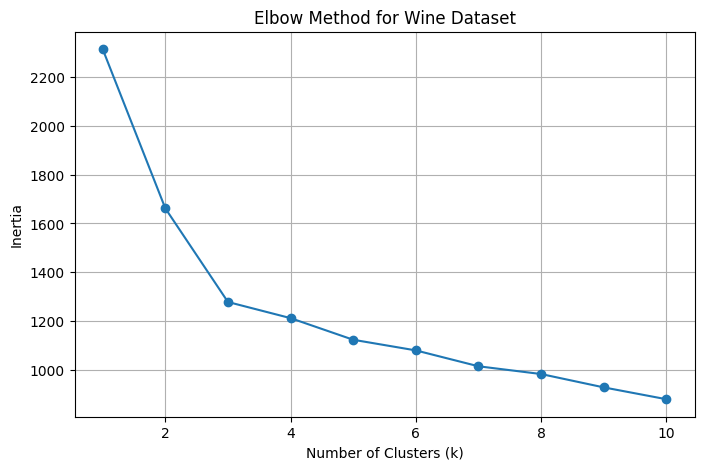

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  Cluster  
0         

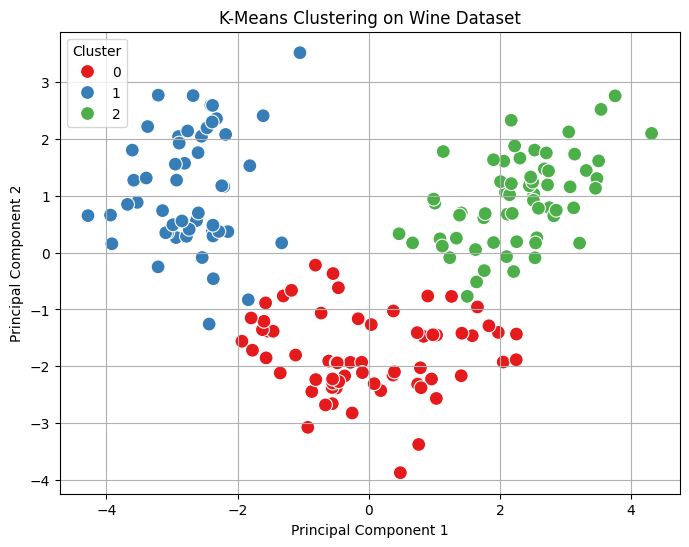


Cluster Counts:
Cluster
0    65
2    62
1    51
Name: count, dtype: int64


In [1]:
# K-Means Clustering using Wine Dataset

# 1. Import Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 2. Load Wine Dataset
wine = load_wine()
X = wine.data

# Convert to DataFrame
df = pd.DataFrame(X, columns=wine.feature_names)

# 3. Standardize the Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Elbow Method to Find Best Number of Clusters
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Wine Dataset')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

# 5. Apply KMeans with k = 3
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# 6. Add Cluster Labels to DataFrame
df['Cluster'] = clusters

# Show First 5 Rows
print(df.head())

# 7. Reduce Dimensions using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Add PCA Components
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

# 8. Visualize Clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    data=df,
    palette='Set1',
    s=100
)

plt.title('K-Means Clustering on Wine Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# 9. Number of Samples in Each Cluster
print("\nCluster Counts:")
print(df['Cluster'].value_counts())